# Approximate Bayesian Computation Worked Example

Veronica Hoffman and Becca Lucas

## Setup

To run this notebook, you will need to install scipy, matplotlib, and numpy.

In this example, we use Approximate Bayesian Computation (ABC) to estimate cosmological parameters from supernovae data. Specifically, we want to estimate the posterior distributions of two parameters:
- Matter density, $\Omega_{m}$: how much of the universe's total energy density is composed of matter, normal and dark. 
- Dark energy equation of state, $w_{0}$: ratio of dark energy's pressure to its energy density: $w =  p/\rho$.

To do this, we will define the distance modulus as a function of redshift $z$, $\Omega_{m}$, and $w_{0}$.

$$\mu_{i}^{model}(z_{i};\Omega_{m},w_{0}) \propto 5log_{10}(\frac{c(1+z)}{h_{0}})\int_{0}^{z}\frac{dz'}{E(z')}$$


$$E(z) = \sqrt{\Omega_{m} (1+z)^{3} + (1-\Omega_{m})e^{3\int_{0}^{z} dln(1+z')[1+w(z')]}}$$

Note that here, a likelihood is not specified (we'd have to specify our own, potentially making incorrect assumptions!), making this the perfect candidate for ABC.

In [1]:
#imports
import numpy as np
from scipy.stats import skewnorm
import matplotlib.pyplot as plt 
from scipy.integrate import quad

In [2]:
#parameters ("true" values)
omega_m_true = 0.3
w_true = -1.0

e = -0.1
w_noise = 0.3
a = 5.0

c = 299792.458
H0 = 70.0

In [3]:
#distance modulus calculation function
def calc_dist_mod(z, omega_m, w):
    omega_lamda = 1 - omega_m
    def E(z_prime):
        return 1.0 / np.sqrt(omega_m * (1 + z_prime)**3 + omega_lamda * (1 + z_prime)**(3*(1+w)))

    integral, _ = quad(E, 0, z)
    d_c = (c / H0) * integral
    d_l = d_c * (1 + z)
    mu = 5 * np.log10(d_l) + 25
    return mu

## Synthetic Dataset

Below, we create a synthetic dataset of supernova light curves to generate values of the distance modulus, $\mu_{i}$ with the fixed "true" parameters $\Omega_{m}$ and $w_{0}$.

In this example, we set the "true" values as follows:

$$\Omega_{m} = 0.3$$
$$w_{0} = -1.0$$

Here, we simulate redshifts from 0.1 to 1.5, calculate the distance modulus from them and the "true" parameters, and add a skewed distribution of noise to that data to mimic real observations.

In [4]:
num_bins = 20
z_min = 0.1 #redshift limits
z_max = 1.5
zbins = np.linspace(z_min, z_max, num_bins)

mu_true = np.array([calc_dist_mod(z, omega_m_true, w_true) for z in zbins]) #calculate distance modulus from redshift and "true" parameters

errors = np.full(num_bins, 0.15) 
np.random.seed(42) #for repeatability
noise = skewnorm.rvs(a, loc=e, scale=w_noise, size=num_bins) #skewed distribution of noise
data_noisy = mu_true + noise #add "true" values and noise together. 

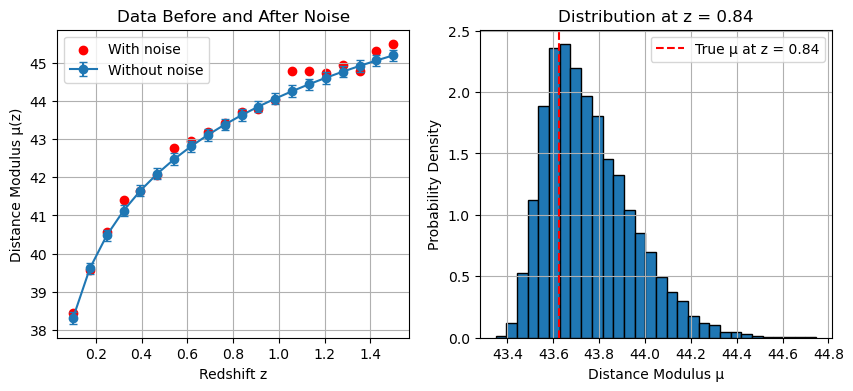

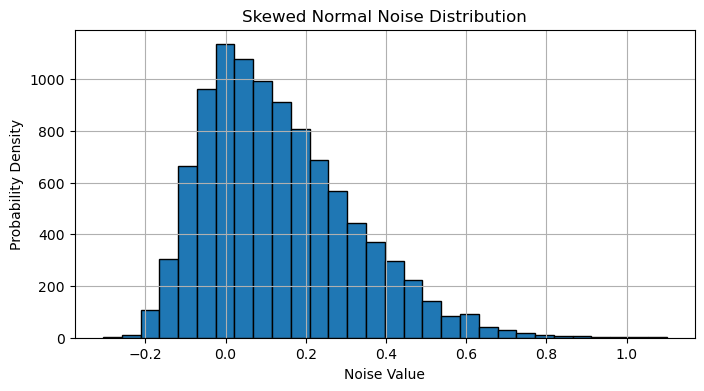

In [5]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1) #plot effect of adding noise
plt.errorbar(zbins, mu_true, errors, label='Without noise', capsize=3, marker = 'o')
plt.scatter(zbins, data_noisy, color='r', label='With noise')
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ(z)')
plt.title('Data Before and After Noise')
plt.legend()
plt.grid()

z_index = 10  
sample_size = 10000
distribution = mu_true[z_index] + skewnorm.rvs(a, loc=e, scale=w_noise, size=sample_size)

plt.subplot(1, 2, 2) #plot the data at a single redshift
plt.hist(distribution, bins=30, density=True, edgecolor='black')
plt.axvline(mu_true[z_index], color='r', linestyle='--', label=f'True μ at z = {zbins[z_index]:.2f}')
plt.xlabel('Distance Modulus μ')
plt.ylabel('Probability Density')
plt.title(f'Distribution at z = {zbins[z_index]:.2f}')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4)) #plot the overall skewed noise distribution
sample_noise = skewnorm.rvs(a, loc=e, scale=w_noise, size=10000)
plt.hist(sample_noise, bins=30, edgecolor='black')
plt.xlabel('Noise Value')
plt.ylabel('Probability Density')
plt.title('Skewed Normal Noise Distribution')
plt.grid()
plt.show()

## Run ABC

First, we have to define a metric that measures how well the simulated data generated from the model matches the true data.

In [6]:
#metric: here, its just distance. Lower values = better fit
def dist(d, x): #d = true data, x = simulated data
    return np.sum(((d - x) / errors) ** 2)

Next, we define the ABC simulation function which should have a prior and calculate the simulated distance modulus.

In [7]:
#ABC simulation function
def ABCsimulation(param):  #[om, w], what we're trying to estimate
    omega_m_sample, w_sample = param
    if omega_m_sample < 0.0 or omega_m_sample > 1.0:  #make sure omega_m value makes logical sense (prior)
        return None  #if parameter is invalid
    model_data = np.zeros(len(zbins))
    for i in range(len(zbins)):
        model_data[i] = calc_dist_mod(zbins[i], omega_m_sample, w_sample) + skewnorm.rvs(a, loc=e, scale=w_noise, size=1)
    return model_data

In [8]:
#initialize data storage for later
results = []
first_iteration_particles = []
last_iteration_particles = []
particles = []

Here, we define the relevant settings for the ABC. In each iteration of ABC, some number particles are generated from the prior distributions. So, in this example each particle is a tuple [$\Omega_{m}$, $w_{0}$] with some estimated value. Then, each particle is used to calculate the distance modulus. Finally, the metric is used to calculate which particles do best. These are passed on to the next iteration of the model, while the others are discarded. This process repeates for some number of iterations.

In [9]:
#ABC parameters
nparam = 2 #numer of parameters (om, w) so 2
npart = 100  #number of particles, fairly arbitrary
niter = 100  #number of iterations, fairly arbitrary

In [10]:
#setup for visualization, ignore this for now!
iterations_to_plot = [1, 20, 40, 60, 80, 100]
particles_to_plot = {}
for iter_num in iterations_to_plot:
    if iter_num <= niter and iter_num > 0:
        particles_to_plot[iter_num] = []

In [11]:
#run ABC iterations!
for iter_num in range(niter):
    new_particles = []
    for _ in range(npart):
        omega_m_sample = np.random.normal(0.3, max(0.1, 0.5 - iter_num * 0.005))
        w_sample = np.random.normal(-1.0, max(0.1, 0.5 - iter_num * 0.005))
        param = [omega_m_sample, w_sample]

        simulated_data = ABCsimulation(param)
        if simulated_data is None:
            continue

        distance = dist(data_noisy, simulated_data)
        results.append((param, distance))
        new_particles.append((param, distance))

    if iter_num + 1 in iterations_to_plot:
        particles_to_plot[iter_num + 1] = new_particles
        
    #only keep the best particles
    if particles:
        particles += new_particles
        particles = sorted(particles, key=lambda x: x[1])[:npart]
    else:
        particles = new_particles

    best_result = sorted(new_particles, key=lambda x: x[1])[0]
    mean_distance = np.mean([res[1] for res in particles])
    print(f"Step {iter_num + 1}: Params: {best_result[0]}")

final_best_result = sorted(results, key=lambda x: x[1])[0]
print("Final best parameter estimate after all iterations:", final_best_result[0])

/var/folders/cz/sjwyhdvx2c52z7qsc2h91r0w0000gn/T/ipykernel_99931/33929862.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model_data[i] = calc_dist_mod(zbins[i], omega_m_sample, w_sample) + skewnorm.rvs(a, loc=e, scale=w_noise, size=1)


Step 1: Params: [0.4061818730144246, -1.5963225814345883]
Step 2: Params: [0.3616638099932482, -1.0709431271520324]
Step 3: Params: [0.26042487124926444, -0.7849405045333434]
Step 4: Params: [0.28864196390446856, -1.1139911336818977]
Step 5: Params: [0.37844880551303506, -0.9219487985017536]
Step 6: Params: [0.3186052047331938, -1.0404825329290255]
Step 7: Params: [0.17058037912995713, -0.6676234430978134]
Step 8: Params: [0.24407666066130623, -1.0534686053905584]
Step 9: Params: [0.27159432051957355, -1.2394855897646933]
Step 10: Params: [0.3365681126150413, -1.318982403662967]
Step 11: Params: [0.37192264635871586, -1.2521192771985852]
Step 12: Params: [0.17871655475244327, -0.7271512782900894]
Step 13: Params: [0.14094078672439175, -0.6190149086858099]
Step 14: Params: [0.48302981765586916, -1.6912758456988581]
Step 15: Params: [0.25345876091166986, -1.1935496651983295]
Step 16: Params: [0.33911631863885583, -1.0603069425453875]
Step 17: Params: [0.31364184846011783, -1.157326589099

If you look closely at the estimated parameters at each step, you can see the values slowly converging towards the ture values, with some amount of "bouncing around".

You'll also notice the final best estimate... isn't that great of an estimation! But its pretty good, especially if you remeber that this process does not define a likelihood and that ABC is best used for approximation, not ultra-precise results!

## Visualization of the ABC Process

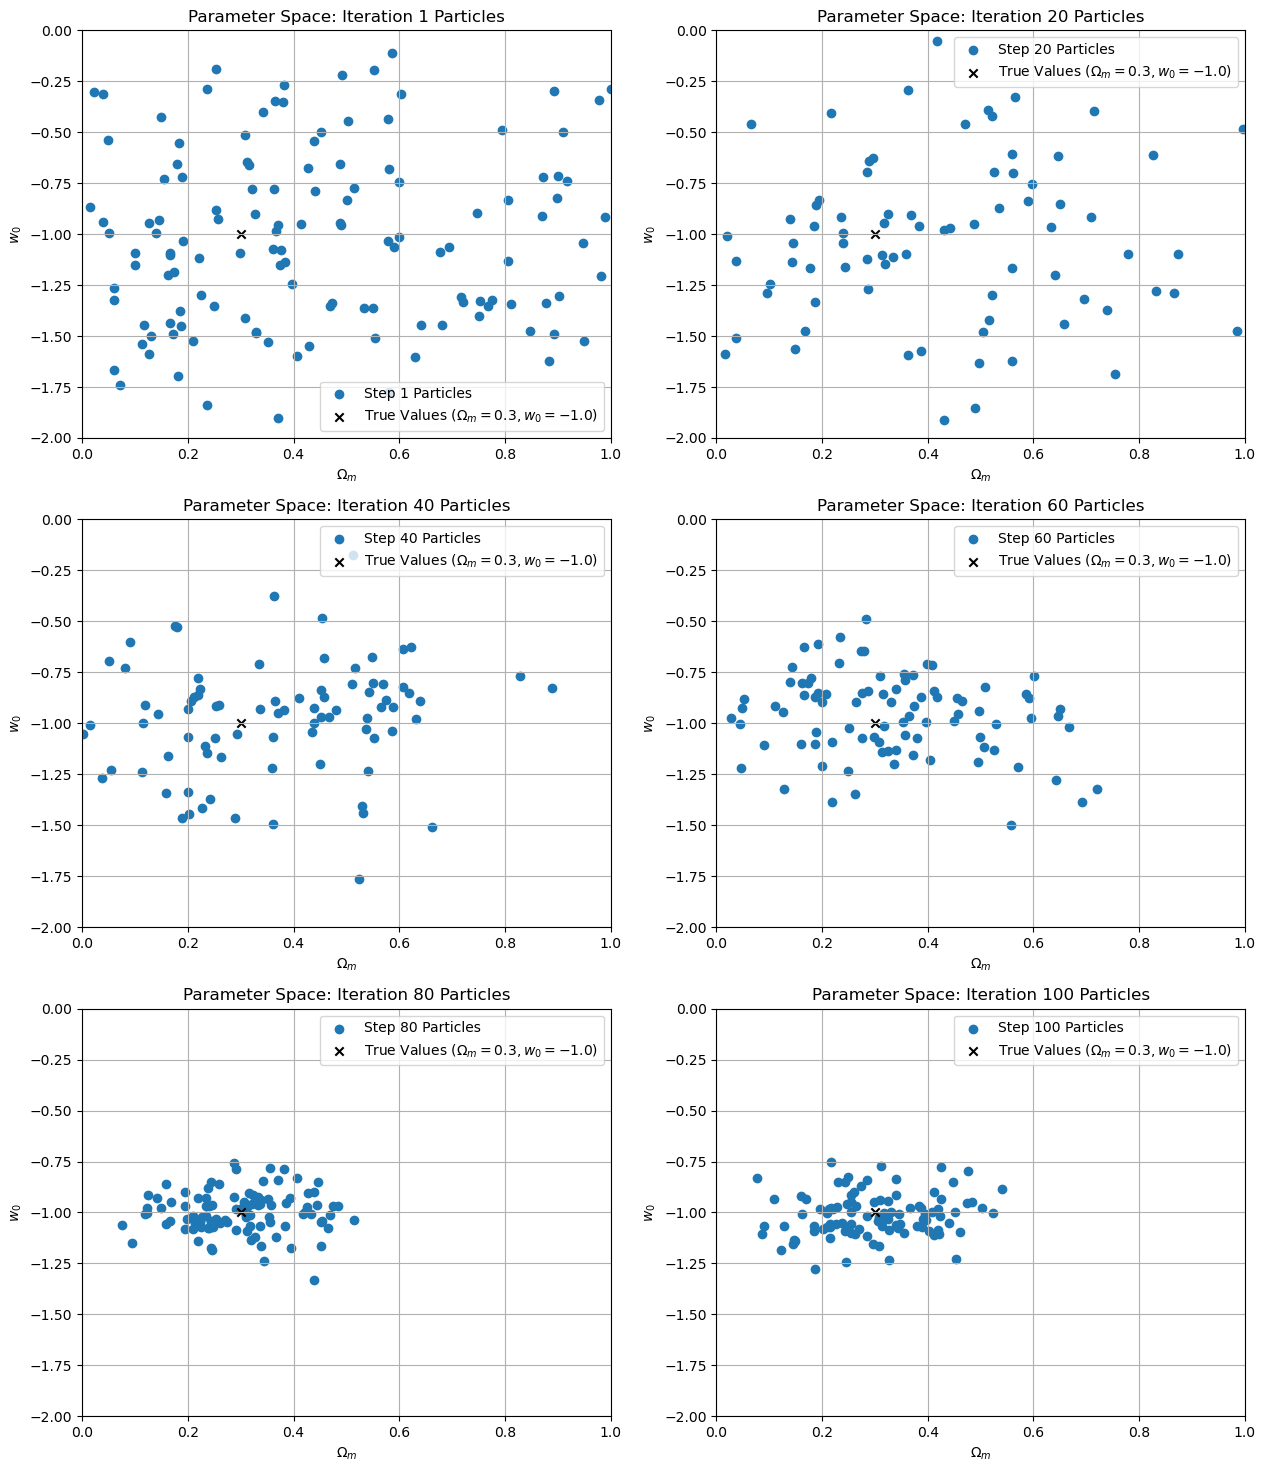

In [12]:
#plotting the process!
fig, axs = plt.subplots(3, 2, figsize = (15, 18))
axs = axs.flatten()

for i, iter_num in enumerate(iterations_to_plot):
    if particles_to_plot[iter_num]:
        particles = np.array([p[0] for p in particles_to_plot[iter_num]])
        axs[i].scatter(particles[:, 0], particles[:, 1], label=f'Step {iter_num} Particles')
    axs[i].scatter(omega_m_true, w_true, color='black', marker='x', label='True Values ($\Omega_m=0.3, w_0=-1.0$)')
    axs[i].set_xlabel('$\Omega_m$')
    axs[i].set_ylabel('$w_0$')
    axs[i].set_title(f'Parameter Space: Iteration {iter_num} Particles')
    axs[i].legend()
    axs[i].grid()
    axs[i].set_xlim(0, 1)
    axs[i].set_ylim(-2, 0)
plt.show()

Here you can clearly see, that as the number of iterations increases, the particles continue to get more and more compact around the location of the true values!

## TLDR

No likelihood? Crazy complex likelihood? -> Use ABC!

1. Sample parameters from prior
2. Simulate data with those parameters (similar to observed data)
3. Compare simulated data with the observed data
4. Accept the parameter set if the simulated data is similar enough to the observed data
5. Repeat until you get enough accepted parameter samples
6. Get a decent estimation!


## References

https://www.astroml.org/astroML-notebooks/chapter5/astroml_chapter5_Approximate_Bayesian_Computation.html

https://github.com/EliseJ/astroABC/tree/master

https://en.wikipedia.org/wiki/Approximate_Bayesian_computation